<a href="https://colab.research.google.com/github/thanu-george/ML-algorithms/blob/main/DecisionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Build a DecisionTree classifier to classify Drugdataset

Use 80% of data for training and 20% for testing. Display accuracy score and confusion matrix of the trained model on test data.


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
# Load dataset
df = pd.read_csv("drug.csv")

# Encode categorical columns
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['BP'] = le.fit_transform(df['BP'])
df['Cholesterol'] = le.fit_transform(df['Cholesterol'])
df['Drug'] = le.fit_transform(df['Drug'])

In [3]:
# Features and target
X = df[['Age','Sex','BP','Cholesterol','Na_to_K']]
y = df['Drug']

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
# Train model
model = DecisionTreeClassifier(criterion='entropy')
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

In [12]:
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0
Confusion Matrix:
 [[ 6  0  0  0  0]
 [ 0  3  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 11  0]
 [ 0  0  0  0 15]]


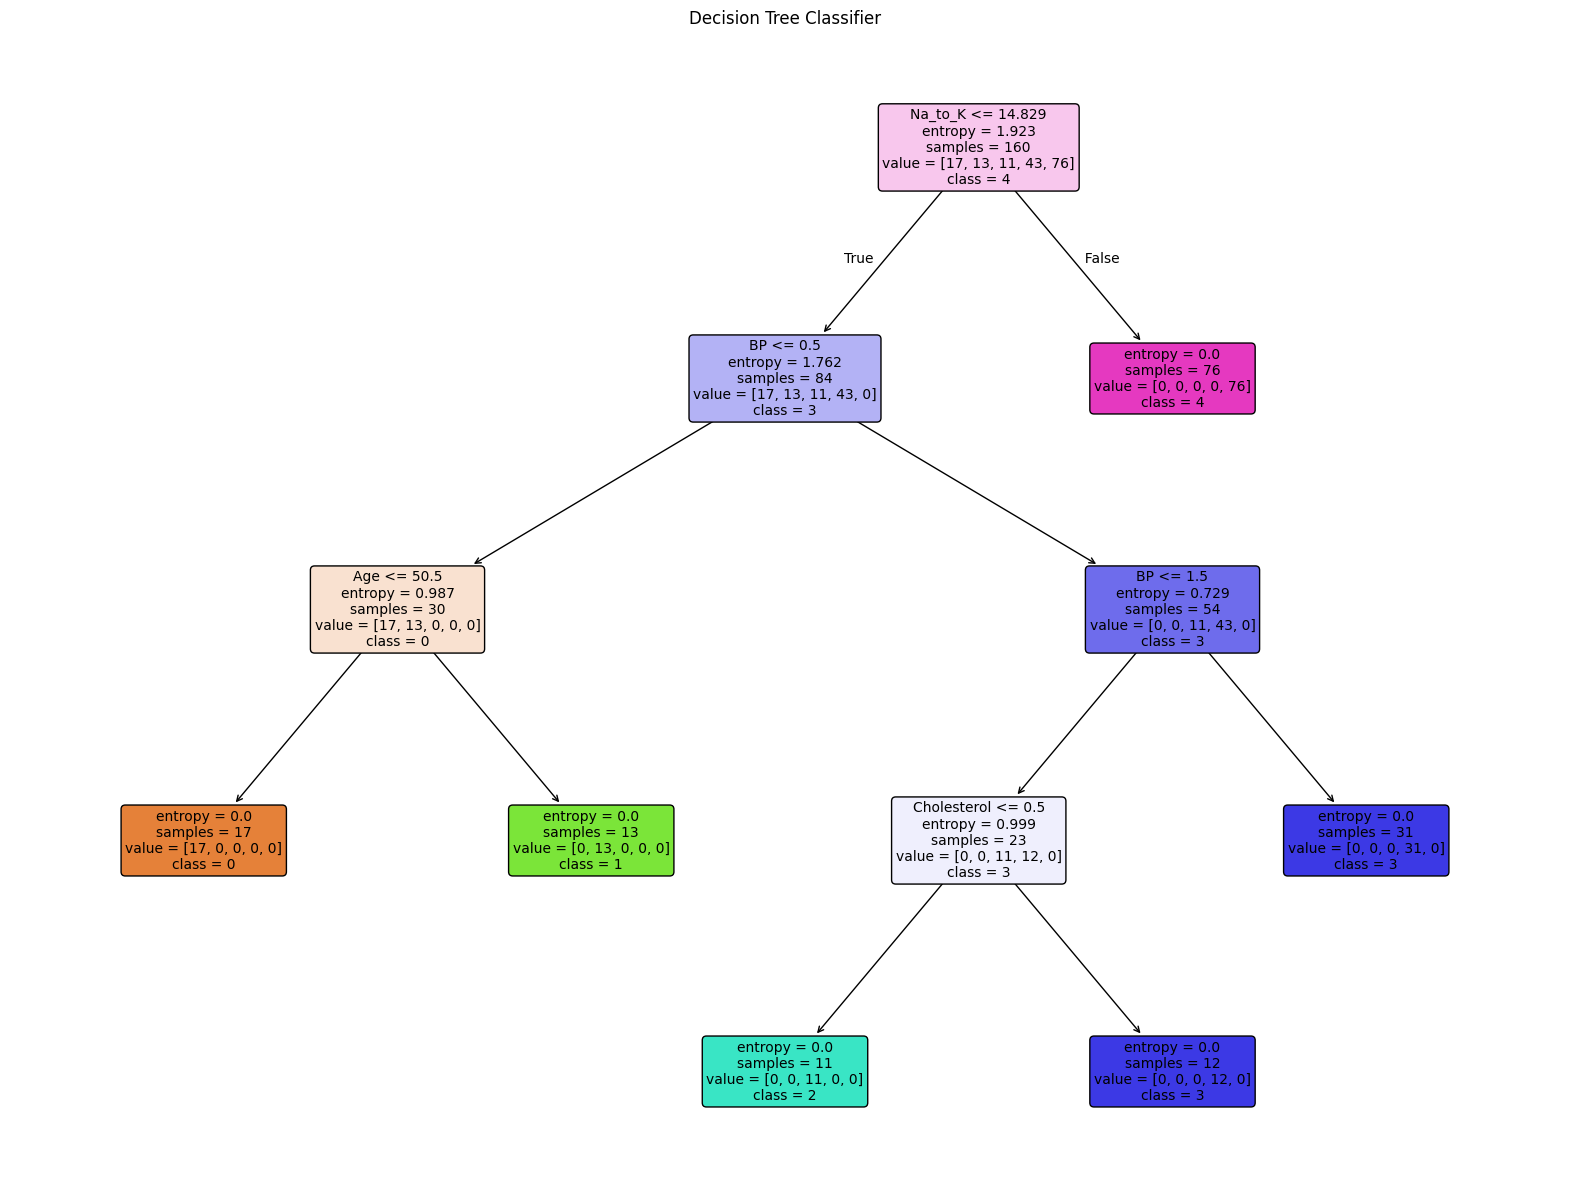

In [11]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Get feature names from X
feature_names = X.columns.tolist()

# Get class names from the target variable y (encoded values)
# Since LabelEncoder was applied directly, we can get unique values from y and convert them to strings.
class_names = [str(x) for x in sorted(y.unique())]

plt.figure(figsize=(20, 15))
plot_tree(model, feature_names=feature_names, class_names=class_names, filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree Classifier")
plt.show()

Write Python code to implement the following.

Consider dataset file “petrol_consumption.csv” Build a RegressionTree to predict petrol consumption Use 80% of data for training and 20% for testing. Display “Mean Absolute Error, Mean Squared Error, Root Mean Squared Error” for test data.

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Load dataset
df = pd.read_csv("petrol_consumption.csv")

# Features and target
X = df[['Petrol_tax','Average_income','Paved_Highways','Population_Driver_licence(%)']]
y = df['Petrol_Consumption']

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [14]:
# Train Regression Tree
model = DecisionTreeRegressor()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Error metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)

Mean Absolute Error: 90.6
Mean Squared Error: 16851.6
Root Mean Squared Error: 129.81371268090285


Regression Tree vs Decision Tree Classifier: A Regression Tree predicts continuous values using error metrics like MSE, whereas a Decision Tree classifier predicts categorical class labels using measures like Gini or Entropy.